In [22]:
import pandas as pd
from sklearn.utils import resample
df = pd.read_csv('diabetes_cleaneddataset.csv')

print("Before balancing:")
print(df['Outcome'].value_counts())

Before balancing:
Outcome
1    3447
0     553
Name: count, dtype: int64


In [24]:
df_majority = df[df['Outcome'] == 1]   
df_minority = df[df['Outcome'] == 0]

In [ ]:
#LOGISTIC REGRESSION

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [25]:
df_minority_upsampled = resample(
    df_minority,
    replace=True,           
    n_samples=len(df_majority), 
    random_state=42
)

In [26]:
df_balanced = pd.concat([df_majority, df_minority_upsampled])

In [27]:
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [28]:
print(df_balanced['Outcome'].value_counts())

Outcome
1    3447
0    3447
Name: count, dtype: int64


In [29]:
df_balanced.to_csv('diabetes_balanced.csv', index=False)

In [30]:
df = pd.read_csv('diabetes_balanced.csv')
df

,Age,Gender,BMI,Glucose_Level,Insulin,Blood_Pressure,Skin_Thickness,Diabetes_Pedigree_Function,HbA1c,Cholesterol,Medication,Outcome
0,-1.823573,-0.869440,1.791014,0.809222,0.748495,-1.620029,-1.167654,0.130256,0.335545,-1.652853,1.073802,1
1,0.008911,-0.869440,0.625615,-0.012409,1.127926,-0.008420,-0.175575,-0.085348,-1.651428,1.804571,-0.135094,0
2,-0.286651,-0.869440,1.391449,0.525901,1.212245,-0.639050,0.455748,-0.611360,0.234122,-0.016203,1.073802,1
3,-0.995999,-0.869440,-1.288969,0.440905,-1.626464,-0.358770,0.636126,-0.004305,-0.300655,-0.016203,-0.135094,1
4,-1.468898,-0.869440,-0.756215,-0.805709,0.818760,1.229483,1.267448,0.014044,-1.167362,0.065630,1.073802,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6889,1.841395,-0.869440,0.009619,-0.012409,-0.361693,-0.008420,0.004803,0.101203,-1.434751,-0.977735,-1.343990,0
6890,-1.528011,1.150165,-0.056976,0.015923,0.931184,0.995916,-0.085386,0.902454,-1.780512,1.006704,1.073802,0
6891,0.481810,-0.869440,0.825398,-1.032366,0.523647,0.762350,-1.618599,0.014044,-1.319497,0.454334,-0.135094,0
6892,0.008911,1.150165,-1.422157,-1.032366,-0.656806,0.575496,0.004803,0.523236,-1.337938,0.822581,-0.135094,0


In [31]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


Training samples: 5515
Testing samples : 1379


In [33]:
model = LogisticRegression()
model.fit(X_train, y_train)

print("\nModel training complete!")



Model training complete!


In [34]:
y_pred = model.predict(X_test)

In [35]:
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", round(accuracy * 100, 2), "%")


Accuracy: 86.58 %


In [36]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[629  70]
 [115 565]]


In [37]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       699
           1       0.89      0.83      0.86       680

    accuracy                           0.87      1379
   macro avg       0.87      0.87      0.87      1379
weighted avg       0.87      0.87      0.87      1379



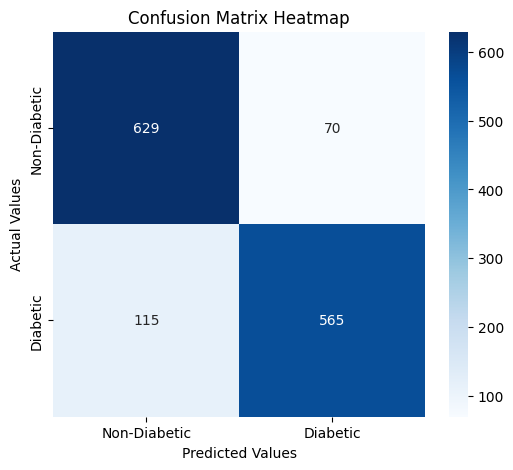

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix Heatmap")

plt.show()

In [1]:
#RANDOM FOREST

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('diabetes_balanced.csv')
df

,Age,Gender,BMI,Glucose_Level,Insulin,Blood_Pressure,Skin_Thickness,Diabetes_Pedigree_Function,HbA1c,Cholesterol,Medication,Outcome
0,-1.823573,-0.869440,1.791014,0.809222,0.748495,-1.620029,-1.167654,0.130256,0.335545,-1.652853,1.073802,1
1,0.008911,-0.869440,0.625615,-0.012409,1.127926,-0.008420,-0.175575,-0.085348,-1.651428,1.804571,-0.135094,0
2,-0.286651,-0.869440,1.391449,0.525901,1.212245,-0.639050,0.455748,-0.611360,0.234122,-0.016203,1.073802,1
3,-0.995999,-0.869440,-1.288969,0.440905,-1.626464,-0.358770,0.636126,-0.004305,-0.300655,-0.016203,-0.135094,1
4,-1.468898,-0.869440,-0.756215,-0.805709,0.818760,1.229483,1.267448,0.014044,-1.167362,0.065630,1.073802,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6889,1.841395,-0.869440,0.009619,-0.012409,-0.361693,-0.008420,0.004803,0.101203,-1.434751,-0.977735,-1.343990,0
6890,-1.528011,1.150165,-0.056976,0.015923,0.931184,0.995916,-0.085386,0.902454,-1.780512,1.006704,1.073802,0
6891,0.481810,-0.869440,0.825398,-1.032366,0.523647,0.762350,-1.618599,0.014044,-1.319497,0.454334,-0.135094,0
6892,0.008911,1.150165,-1.422157,-1.032366,-0.656806,0.575496,0.004803,0.523236,-1.337938,0.822581,-0.135094,0


In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (6894, 12)


In [4]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 5515
Testing samples : 1379


In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("\nRandom Forest Model training complete!")



Random Forest Model training complete!


In [8]:
y_pred = rf.predict(X_test)

In [9]:
accuracy = accuracy_score(y_test, y_pred)
print("\n" + "="*40)
print("    RANDOM FOREST RESULTS")
print("="*40)
print(f"  Accuracy : {round(accuracy * 100, 2)} %")



    RANDOM FOREST RESULTS
  Accuracy : 99.13 %


In [10]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Confusion Matrix:
[[699   0]
 [ 12 668]]


In [11]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Not Diabetic', 'Diabetic']))


Classification Report:
              precision    recall  f1-score   support

Not Diabetic       0.98      1.00      0.99       699
    Diabetic       1.00      0.98      0.99       680

    accuracy                           0.99      1379
   macro avg       0.99      0.99      0.99      1379
weighted avg       0.99      0.99      0.99      1379



In [12]:
print("\n" + "="*40)
print("  FEATURE IMPORTANCE")
print("="*40)
importance_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

for _, row in importance_df.iterrows():
    print(f"  {row['Feature']:<30} : {row['Importance']:.4f}")


  FEATURE IMPORTANCE
  HbA1c                          : 0.5757
  Glucose_Level                  : 0.2572
  Insulin                        : 0.0266
  BMI                            : 0.0257
  Diabetes_Pedigree_Function     : 0.0248
  Cholesterol                    : 0.0233
  Age                            : 0.0204
  Blood_Pressure                 : 0.0203
  Skin_Thickness                 : 0.0169
  Medication                     : 0.0052
  Gender                         : 0.0038


In [13]:
print("\n" + "="*40)
print("  FINDING BEST NUMBER OF TREES")
print("="*40)
for n in [10, 50, 100, 200]:
    rf_n = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_n.fit(X_train, y_train)
    acc = round(accuracy_score(y_test, rf_n.predict(X_test)) * 100, 2)
    print(f"  Trees = {n:<5} → Accuracy = {acc} %")


  FINDING BEST NUMBER OF TREES
  Trees = 10    → Accuracy = 98.98 %
  Trees = 50    → Accuracy = 99.06 %
  Trees = 100   → Accuracy = 99.13 %
  Trees = 200   → Accuracy = 99.13 %


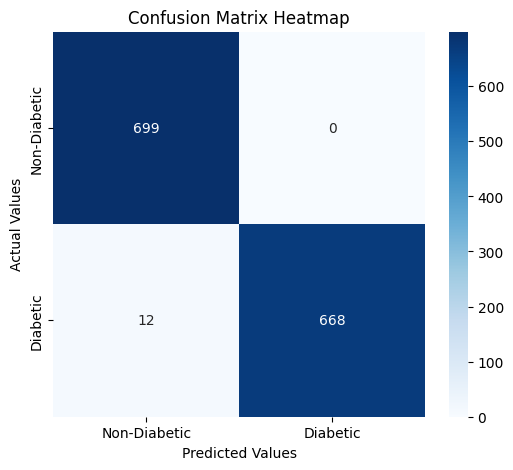

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix Heatmap")

plt.show()

In [14]:
#KMEANS

In [15]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
df = pd.read_csv('diabetes_balanced.csv')
df

,Age,Gender,BMI,Glucose_Level,Insulin,Blood_Pressure,Skin_Thickness,Diabetes_Pedigree_Function,HbA1c,Cholesterol,Medication,Outcome
0,-1.823573,-0.869440,1.791014,0.809222,0.748495,-1.620029,-1.167654,0.130256,0.335545,-1.652853,1.073802,1
1,0.008911,-0.869440,0.625615,-0.012409,1.127926,-0.008420,-0.175575,-0.085348,-1.651428,1.804571,-0.135094,0
2,-0.286651,-0.869440,1.391449,0.525901,1.212245,-0.639050,0.455748,-0.611360,0.234122,-0.016203,1.073802,1
3,-0.995999,-0.869440,-1.288969,0.440905,-1.626464,-0.358770,0.636126,-0.004305,-0.300655,-0.016203,-0.135094,1
4,-1.468898,-0.869440,-0.756215,-0.805709,0.818760,1.229483,1.267448,0.014044,-1.167362,0.065630,1.073802,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6889,1.841395,-0.869440,0.009619,-0.012409,-0.361693,-0.008420,0.004803,0.101203,-1.434751,-0.977735,-1.343990,0
6890,-1.528011,1.150165,-0.056976,0.015923,0.931184,0.995916,-0.085386,0.902454,-1.780512,1.006704,1.073802,0
6891,0.481810,-0.869440,0.825398,-1.032366,0.523647,0.762350,-1.618599,0.014044,-1.319497,0.454334,-0.135094,0
6892,0.008911,1.150165,-1.422157,-1.032366,-0.656806,0.575496,0.004803,0.523236,-1.337938,0.822581,-0.135094,0


In [16]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']


In [17]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [18]:
labels = kmeans.labels_

In [19]:
if accuracy_score(y, labels) < 0.5:
    labels = 1 - labels

In [20]:
accuracy = accuracy_score(y, labels)
print("\n" + "="*40)
print("      K-MEANS RESULTS")
print("="*40)
print(f"  Accuracy : {round(accuracy * 100, 2)} %")


      K-MEANS RESULTS
  Accuracy : 50.7 %


In [21]:
print("\nConfusion Matrix:")
print(confusion_matrix(y, labels))


Confusion Matrix:
[[2004 1443]
 [1956 1491]]


In [22]:
print("\nClassification Report:")
print(classification_report(y, labels,
      target_names=['Not Diabetic', 'Diabetic']))



Classification Report:
              precision    recall  f1-score   support

Not Diabetic       0.51      0.58      0.54      3447
    Diabetic       0.51      0.43      0.47      3447

    accuracy                           0.51      6894
   macro avg       0.51      0.51      0.50      6894
weighted avg       0.51      0.51      0.50      6894



In [23]:
print("\n" + "="*40)
print("  CLUSTER CENTERS")
print("="*40)
centers_df = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)
print(centers_df.T.rename(columns={0: 'Cluster 0', 1: 'Cluster 1'}))

print("\nK-Means complete!")


  CLUSTER CENTERS
                            Cluster 0  Cluster 1
Age                          0.029260   0.007344
Gender                       1.150165  -0.869440
BMI                         -0.031339   0.034331
Glucose_Level               -0.329335  -0.282988
Insulin                      0.049197  -0.003827
Blood_Pressure               0.003362  -0.017061
Skin_Thickness               0.039692  -0.014989
Diabetes_Pedigree_Function  -0.001707   0.005219
HbA1c                       -0.498309  -0.520354
Cholesterol                  0.015530   0.010568
Medication                   0.068861  -0.038627

K-Means complete!


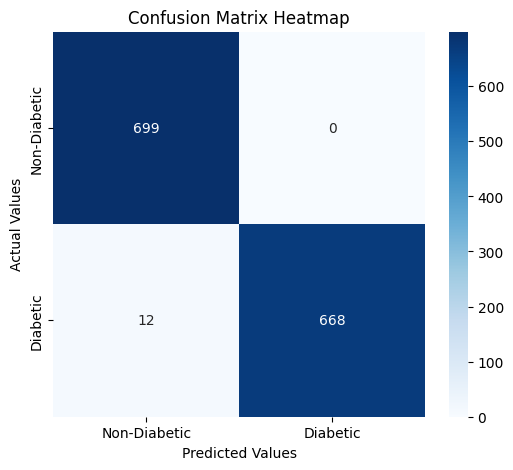

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix Heatmap")

plt.show()

In [26]:
#LINEAR REGRESSION

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

df = pd.read_csv('diabetes_balanced.csv')
df

,Age,Gender,BMI,Glucose_Level,Insulin,Blood_Pressure,Skin_Thickness,Diabetes_Pedigree_Function,HbA1c,Cholesterol,Medication,Outcome
0,-1.823573,-0.869440,1.791014,0.809222,0.748495,-1.620029,-1.167654,0.130256,0.335545,-1.652853,1.073802,1
1,0.008911,-0.869440,0.625615,-0.012409,1.127926,-0.008420,-0.175575,-0.085348,-1.651428,1.804571,-0.135094,0
2,-0.286651,-0.869440,1.391449,0.525901,1.212245,-0.639050,0.455748,-0.611360,0.234122,-0.016203,1.073802,1
3,-0.995999,-0.869440,-1.288969,0.440905,-1.626464,-0.358770,0.636126,-0.004305,-0.300655,-0.016203,-0.135094,1
4,-1.468898,-0.869440,-0.756215,-0.805709,0.818760,1.229483,1.267448,0.014044,-1.167362,0.065630,1.073802,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6889,1.841395,-0.869440,0.009619,-0.012409,-0.361693,-0.008420,0.004803,0.101203,-1.434751,-0.977735,-1.343990,0
6890,-1.528011,1.150165,-0.056976,0.015923,0.931184,0.995916,-0.085386,0.902454,-1.780512,1.006704,1.073802,0
6891,0.481810,-0.869440,0.825398,-1.032366,0.523647,0.762350,-1.618599,0.014044,-1.319497,0.454334,-0.135094,0
6892,0.008911,1.150165,-1.422157,-1.032366,-0.656806,0.575496,0.004803,0.523236,-1.337938,0.822581,-0.135094,0


In [28]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [30]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
y_pred_raw = model.predict(X_test)

In [32]:
y_pred = np.where(y_pred_raw >= 0.5, 1, 0)

In [33]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 84.77 %


In [34]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Confusion Matrix:
[[634  65]
 [145 535]]


In [35]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Diabetic', 'Diabetic']))


Classification Report:
              precision    recall  f1-score   support

Not Diabetic       0.81      0.91      0.86       699
    Diabetic       0.89      0.79      0.84       680

    accuracy                           0.85      1379
   macro avg       0.85      0.85      0.85      1379
weighted avg       0.85      0.85      0.85      1379



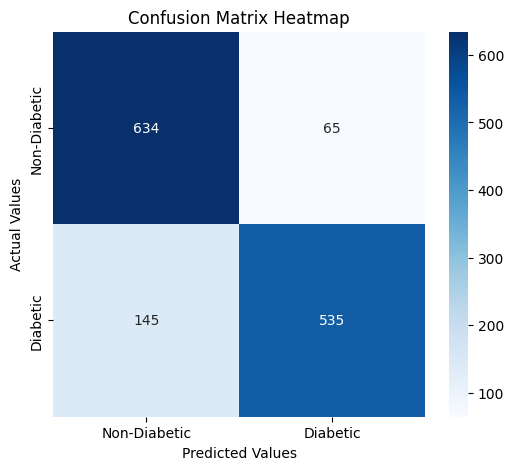

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix Heatmap")

plt.show()

In [37]:
#KNN

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('diabetes_balanced.csv')
df

,Age,Gender,BMI,Glucose_Level,Insulin,Blood_Pressure,Skin_Thickness,Diabetes_Pedigree_Function,HbA1c,Cholesterol,Medication,Outcome
0,-1.823573,-0.869440,1.791014,0.809222,0.748495,-1.620029,-1.167654,0.130256,0.335545,-1.652853,1.073802,1
1,0.008911,-0.869440,0.625615,-0.012409,1.127926,-0.008420,-0.175575,-0.085348,-1.651428,1.804571,-0.135094,0
2,-0.286651,-0.869440,1.391449,0.525901,1.212245,-0.639050,0.455748,-0.611360,0.234122,-0.016203,1.073802,1
3,-0.995999,-0.869440,-1.288969,0.440905,-1.626464,-0.358770,0.636126,-0.004305,-0.300655,-0.016203,-0.135094,1
4,-1.468898,-0.869440,-0.756215,-0.805709,0.818760,1.229483,1.267448,0.014044,-1.167362,0.065630,1.073802,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6889,1.841395,-0.869440,0.009619,-0.012409,-0.361693,-0.008420,0.004803,0.101203,-1.434751,-0.977735,-1.343990,0
6890,-1.528011,1.150165,-0.056976,0.015923,0.931184,0.995916,-0.085386,0.902454,-1.780512,1.006704,1.073802,0
6891,0.481810,-0.869440,0.825398,-1.032366,0.523647,0.762350,-1.618599,0.014044,-1.319497,0.454334,-0.135094,0
6892,0.008911,1.150165,-1.422157,-1.032366,-0.656806,0.575496,0.004803,0.523236,-1.337938,0.822581,-0.135094,0


In [39]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 5515
Testing samples : 1379


In [42]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("\nKNN Model training complete!")



KNN Model training complete!


In [43]:
y_pred = knn.predict(X_test)

In [44]:
accuracy = accuracy_score(y_test, y_pred)
print("\n" + "="*40)
print("       KNN RESULTS (K=5)")
print("="*40)
print(f"  Accuracy : {round(accuracy * 100, 2)} %")


       KNN RESULTS (K=5)
  Accuracy : 88.4 %


In [45]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[673  26]
 [134 546]]


In [46]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Diabetic', 'Diabetic']))



Classification Report:
              precision    recall  f1-score   support

Not Diabetic       0.83      0.96      0.89       699
    Diabetic       0.95      0.80      0.87       680

    accuracy                           0.88      1379
   macro avg       0.89      0.88      0.88      1379
weighted avg       0.89      0.88      0.88      1379



In [47]:
print("\n" + "="*40)
print("  FINDING BEST K VALUE")
print("="*40)
for k in [3, 5, 7, 9, 11]:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    y_pred_k = knn_k.predict(X_test)
    acc = round(accuracy_score(y_test, y_pred_k) * 100, 2)
    print(f"  K = {k}  →  Accuracy = {acc} %")


  FINDING BEST K VALUE
  K = 3  →  Accuracy = 92.75 %
  K = 5  →  Accuracy = 88.4 %
  K = 7  →  Accuracy = 87.16 %
  K = 9  →  Accuracy = 86.66 %
  K = 11  →  Accuracy = 87.02 %


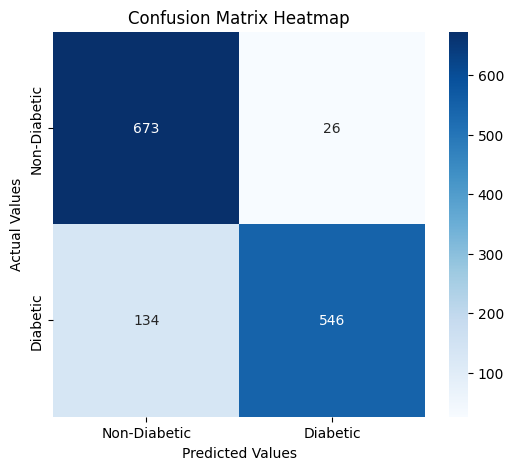

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix Heatmap")

plt.show()

In [49]:
#DECISION TREE

In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('diabetes_balanced.csv')
df

,Age,Gender,BMI,Glucose_Level,Insulin,Blood_Pressure,Skin_Thickness,Diabetes_Pedigree_Function,HbA1c,Cholesterol,Medication,Outcome
0,-1.823573,-0.869440,1.791014,0.809222,0.748495,-1.620029,-1.167654,0.130256,0.335545,-1.652853,1.073802,1
1,0.008911,-0.869440,0.625615,-0.012409,1.127926,-0.008420,-0.175575,-0.085348,-1.651428,1.804571,-0.135094,0
2,-0.286651,-0.869440,1.391449,0.525901,1.212245,-0.639050,0.455748,-0.611360,0.234122,-0.016203,1.073802,1
3,-0.995999,-0.869440,-1.288969,0.440905,-1.626464,-0.358770,0.636126,-0.004305,-0.300655,-0.016203,-0.135094,1
4,-1.468898,-0.869440,-0.756215,-0.805709,0.818760,1.229483,1.267448,0.014044,-1.167362,0.065630,1.073802,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6889,1.841395,-0.869440,0.009619,-0.012409,-0.361693,-0.008420,0.004803,0.101203,-1.434751,-0.977735,-1.343990,0
6890,-1.528011,1.150165,-0.056976,0.015923,0.931184,0.995916,-0.085386,0.902454,-1.780512,1.006704,1.073802,0
6891,0.481810,-0.869440,0.825398,-1.032366,0.523647,0.762350,-1.618599,0.014044,-1.319497,0.454334,-0.135094,0
6892,0.008911,1.150165,-1.422157,-1.032366,-0.656806,0.575496,0.004803,0.523236,-1.337938,0.822581,-0.135094,0


In [51]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [53]:
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


Training samples: 5515
Testing samples : 1379


In [54]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [55]:
y_pred = dt.predict(X_test)

In [56]:
accuracy = accuracy_score(y_test, y_pred)
print("\n" + "="*40)
print("    DECISION TREE RESULTS")
print("="*40)
print(f"  Accuracy : {round(accuracy * 100, 2)} %")


    DECISION TREE RESULTS
  Accuracy : 99.13 %


In [57]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Confusion Matrix:
[[699   0]
 [ 12 668]]


In [58]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Not Diabetic', 'Diabetic']))


Classification Report:
              precision    recall  f1-score   support

Not Diabetic       0.98      1.00      0.99       699
    Diabetic       1.00      0.98      0.99       680

    accuracy                           0.99      1379
   macro avg       0.99      0.99      0.99      1379
weighted avg       0.99      0.99      0.99      1379



In [62]:
print("\n" + "="*40)
print("  FEATURE IMPORTANCE")
print("="*40)
importance_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

for _, row in importance_df.iterrows():
    print(f"  {row['Feature']:<30} : {row['Importance']:.4f}")



  FEATURE IMPORTANCE
  HbA1c                          : 0.6628
  Glucose_Level                  : 0.2322
  Insulin                        : 0.0199
  Blood_Pressure                 : 0.0188
  BMI                            : 0.0174
  Diabetes_Pedigree_Function     : 0.0170
  Age                            : 0.0107
  Cholesterol                    : 0.0102
  Gender                         : 0.0041
  Skin_Thickness                 : 0.0039
  Medication                     : 0.0031


In [63]:
print("\n" + "="*40)
print("  FINDING BEST TREE DEPTH")
print("="*40)
for depth in [3, 5, 7, 10, None]:
    dt_d = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_d.fit(X_train, y_train)
    acc = round(accuracy_score(y_test, dt_d.predict(X_test)) * 100, 2)
    depth_label = str(depth) if depth else 'Full'
    print(f"  Depth = {depth_label:<5} → Accuracy = {acc} %")

print("\nDecision Tree complete!")


  FINDING BEST TREE DEPTH
  Depth = 3     → Accuracy = 93.11 %
  Depth = 5     → Accuracy = 96.16 %
  Depth = 7     → Accuracy = 96.52 %
  Depth = 10    → Accuracy = 97.53 %
  Depth = Full  → Accuracy = 99.13 %

Decision Tree complete!


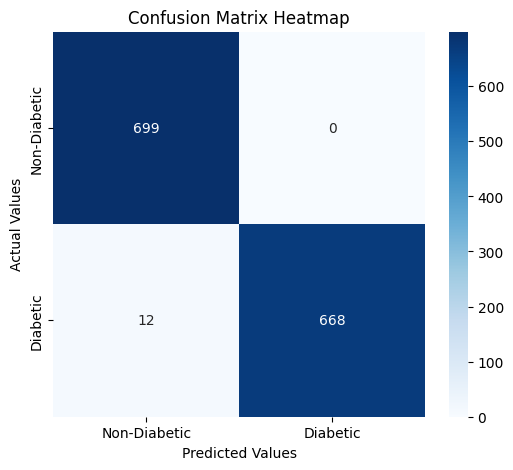

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix Heatmap")

plt.show()

In [ ]:
#logistic Regression : Best for Clinical Assessment :Accuracy: 86.58%
